In [1]:
import tensorflow as tf
import numpy as np

### 1) Loading Data

In [2]:
landmarks_data = np.load('../../../data/divided/landmarks_dataset.npz')

# Extract the individual arrays using their keys
X_train_landmarks = landmarks_data['X_train']
y_train_landmarks = landmarks_data['y_train']
X_test_landmarks = landmarks_data['X_test']
y_test_landmarks = landmarks_data['y_test']

images_data = np.load('../../../data/divided/images_dataset.npz')

# Extract the individual arrays using their keys
X_train_images = images_data['X_train']
y_train_images = images_data['y_train']
X_test_images = images_data['X_test']
y_test_images = images_data['y_test']


In [3]:
print(X_train_landmarks.shape)
print(y_train_landmarks.shape)
print(X_test_landmarks.shape)
print(y_test_landmarks.shape)

(6071, 21, 3)
(6071,)
(1302, 21, 3)
(1302,)


### 2) Defining Resnet model architecutre

In [4]:
# Architectures.
#
# build_mlp: 3-layer MLP (was previously misnamed `build_resnet`). Works on the
#   (21, 3) landmark inputs because that's already a low-dim, hand-curated
#   representation. Collapsed to uniform output when fed flattened 64x64x3
#   pixels — see trained-models/_backup_pre_rerun/.
# build_resnet_images: ResNet50 with frozen ImageNet weights + Dense head.

import tensorflow as tf
import keras
from keras.applications import ResNet50
from keras.applications.resnet import preprocess_input as resnet_preprocess


@keras.saving.register_keras_serializable(package="letters_asl")
class ResnetImagesPreprocess(tf.keras.layers.Layer):
    """Cast uint8 [0,255] -> float32 and apply Keras ResNet preprocessing
    (BGR swap + per-channel ImageNet mean subtraction). Registered as a
    serializable layer so the saved .h5 reloads cleanly without lambda hacks."""

    def call(self, inputs):
        x = tf.cast(inputs, tf.float32)
        return resnet_preprocess(x)

    def compute_output_shape(self, input_shape):
        return input_shape


def build_mlp(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Flatten()(inputs)
    x = tf.keras.layers.Dense(512, activation="relu")(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)


def build_resnet_images(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)
    x = ResnetImagesPreprocess()(inputs)
    base = ResNet50(weights="imagenet", include_top=False, input_tensor=x)
    base.trainable = False
    x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)


# Backwards-compat alias: cells that still reference `build_resnet` (landmarks
# path + hyperopt search) want the MLP — that's the model that works on the
# (21, 3) landmark inputs.
build_resnet = build_mlp


### 3) Training Resnet model on Images data

In [5]:
# Define input shape and number of classes
input_shape = X_train_images.shape[1:]  # Shape of one sample
num_classes = len(np.unique(y_train_images))  # Number of unique labels

# Build the real ResNet (frozen ImageNet backbone + Dense head).
resnet_images_model = build_resnet_images(input_shape, num_classes)

# Compile the model
resnet_images_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Train the model
resnet_images_model.fit(X_train_images, y_train_images, epochs=10, batch_size=32)


Epoch 1/10


  1/285 ━━━━━━━━━━━━━━━━━━━━ 7:27 2s/step - accuracy: 0.0000e+00 - loss: 8.0174

  2/285 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.0000e+00 - loss: 7.8093

  3/285 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.0000e+00 - loss: 7.7254

  4/285 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.0020 - loss: 7.6209    

...

281/285 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9155 - loss: 0.2534

282/285 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9155 - loss: 0.2534

283/285 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9155 - loss: 0.2534

284/285 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9155 - loss: 0.2534

285/285 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.9138 - loss: 0.2582


In [6]:
# Evaluate the model on the test data
test_loss, test_accuracy = resnet_images_model.evaluate(X_test_images, y_test_images)
print(f'accuracy {test_accuracy}')

 1/61 ━━━━━━━━━━━━━━━━━━━━ 37s 631ms/step - accuracy: 1.0000 - loss: 0.0436

 2/61 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 1.0000 - loss: 0.0504  

 3/61 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9965 - loss: 0.0560

 4/61 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9954 - loss: 0.0560

 5/61 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9951 - loss: 0.0560

...

59/61 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9814 - loss: 0.0799

60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9813 - loss: 0.0803

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9812 - loss: 0.0807

61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9733 - loss: 0.1049


accuracy 0.9733333587646484


#### Saving model for persistance

In [7]:
resnet_images_model.save('../../../trained-models/resnet_images_model.h5')

### 4) Training Resnet model on Landmarks data

In [8]:
# Define input shape and number of classes
input_shape = X_train_landmarks.shape[1:]  # Shape of one sample
num_classes = len(np.unique(y_train_landmarks))  # Number of unique labels

# Build the model
resnet_landmarks_model = build_resnet(input_shape, num_classes)

# Compile the model
resnet_landmarks_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
resnet_landmarks_model.fit(X_train_landmarks, y_train_landmarks, epochs=10)

Epoch 1/10


  1/190 ━━━━━━━━━━━━━━━━━━━━ 43s 229ms/step - accuracy: 0.0312 - loss: 3.3037

 50/190 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0969 - loss: 3.2034   

101/190 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1344 - loss: 3.0918

152/190 ━━━━━━━━━━━━━━━━━━━━ 0s 1000us/step - accuracy: 0.1716 - loss: 2.9616

...

  1/190 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8750 - loss: 0.7013

 56/190 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step - accuracy: 0.8833 - loss: 0.4392

114/190 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - accuracy: 0.8873 - loss: 0.4138

173/190 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - accuracy: 0.8886 - loss: 0.4052

190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - accuracy: 0.8929 - loss: 0.3834


In [9]:
# Evaluate the model on the test data
test_loss, landamrks_test_accuracy = resnet_landmarks_model.evaluate(X_test_landmarks, y_test_landmarks)
accuracy_before = landamrks_test_accuracy
print(f'accuracy {landamrks_test_accuracy}')

 1/41 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8750 - loss: 0.3229

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 610us/step - accuracy: 0.8894 - loss: 0.3930


accuracy 0.8894008994102478


#### Saving model for persistance

In [10]:
resnet_landmarks_model.save('../../../trained-models/resnet_landmarks_model.h5')

### 5) Applying Hyperparameter Tuning

#### 5.1) Resnet Landmarks

##### using bayesian optimization

In [11]:
from keras.optimizers import Adam, RMSprop
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import numpy as np

/Users/jadantoun/Desktop/final-ml/Sign Language Python/.venv/lib/python3.12/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [12]:
# function to build the model
def build_resnet_model(input_shape, num_classes, optimizer, learning_rate):
    model = build_resnet(input_shape, num_classes)
    optimizer_instance = optimizer(learning_rate=learning_rate)
    model.compile(optimizer=optimizer_instance, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [13]:
# Define input shape and number of classes
input_shape = X_train_landmarks.shape[1:] 
num_classes = len(np.unique(y_train_landmarks)) 

In [14]:
# function to evaluate each set of hyperparameters.

def objective(params):
    model = build_resnet_model(
        input_shape=input_shape, 
        num_classes=num_classes, 
        optimizer=params['optimizer'], 
        learning_rate=params['learning_rate']
    )
    
    history = model.fit(
        X_train_landmarks, y_train_landmarks, 
        epochs=params['epochs'], 
        batch_size=params['batch_size'], 
        verbose=0, 
        validation_split=0.2
    )
    
    best_accuracy = max(history.history['val_accuracy'])
    return {'loss': -best_accuracy, 'status': STATUS_OK}


In [15]:
# Specify the range of hyperparameters to search.
search_space = {
    'optimizer': hp.choice('optimizer', [Adam, RMSprop]),
    'learning_rate': hp.loguniform('learning_rate', np.log(1e-5), np.log(1e-2)),
    'epochs': hp.choice('epochs', [10, 20, 30]),
    'batch_size': hp.choice('batch_size', [32, 64, 128])
}


In [16]:
# Run the optimization process to find the best hyperparameters.
trials = Trials()
best = fmin(fn=objective, space=search_space, algo=tpe.suggest, max_evals=5, trials=trials)

print("Best hyperparameters:", best)


  0%|          | 0/5 [00:00<?, ?trial/s, best loss=?]

 20%|██        | 1/5 [00:02<00:11,  2.96s/trial, best loss: -0.9251028895378113]

 40%|████      | 2/5 [00:05<00:08,  2.89s/trial, best loss: -0.9251028895378113]

 60%|██████    | 3/5 [00:08<00:05,  2.67s/trial, best loss: -0.9251028895378113]

 80%|████████  | 4/5 [00:12<00:03,  3.50s/trial, best loss: -0.9251028895378113]

100%|██████████| 5/5 [00:17<00:00,  3.94s/trial, best loss: -0.9251028895378113]

100%|██████████| 5/5 [00:17<00:00,  3.54s/trial, best loss: -0.9251028895378113]


Best hyperparameters: {'batch_size': 2, 'epochs': 2, 'learning_rate': 0.0034881008288207777, 'optimizer': 0}


In [17]:
# use these parameters to train the final model.

# Map the best hyperparameters back to their actual values
best_params = {
    'optimizer': [Adam, RMSprop][best['optimizer']],
    'learning_rate': best['learning_rate'],
    'epochs': [10, 20, 30][best['epochs']],
    'batch_size': [32, 64, 128][best['batch_size']]
}

# Build and train the final model with the best hyperparameters
final_model = build_resnet_model(
    input_shape=input_shape, 
    num_classes=num_classes, 
    optimizer=best_params['optimizer'], 
    learning_rate=best_params['learning_rate']
)

final_model.fit(
    X_train_landmarks, y_train_landmarks, 
    epochs=best_params['epochs'], 
    batch_size=best_params['batch_size']
)


Epoch 1/30


 1/48 ━━━━━━━━━━━━━━━━━━━━ 11s 241ms/step - accuracy: 0.0156 - loss: 3.2916

31/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1376 - loss: 3.0526   

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3278 - loss: 2.4356


Epoch 2/30


...

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9382 - loss: 0.2017


Epoch 30/30


 1/48 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9766 - loss: 0.0791

35/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9475 - loss: 0.1756 

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9417 - loss: 0.1891


In [18]:
test_loss, landamrks_test_accuracy = final_model.evaluate(X_test_landmarks, y_test_landmarks)
accuracy_after = landamrks_test_accuracy
print(f'accuracy {landamrks_test_accuracy}')

 1/41 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9688 - loss: 0.1607

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step - accuracy: 0.9332 - loss: 0.2602


accuracy 0.9331797361373901


In [19]:
# save tuned model
final_model.save('../../../trained-models/resnet_landmarks_tuned_model.h5')

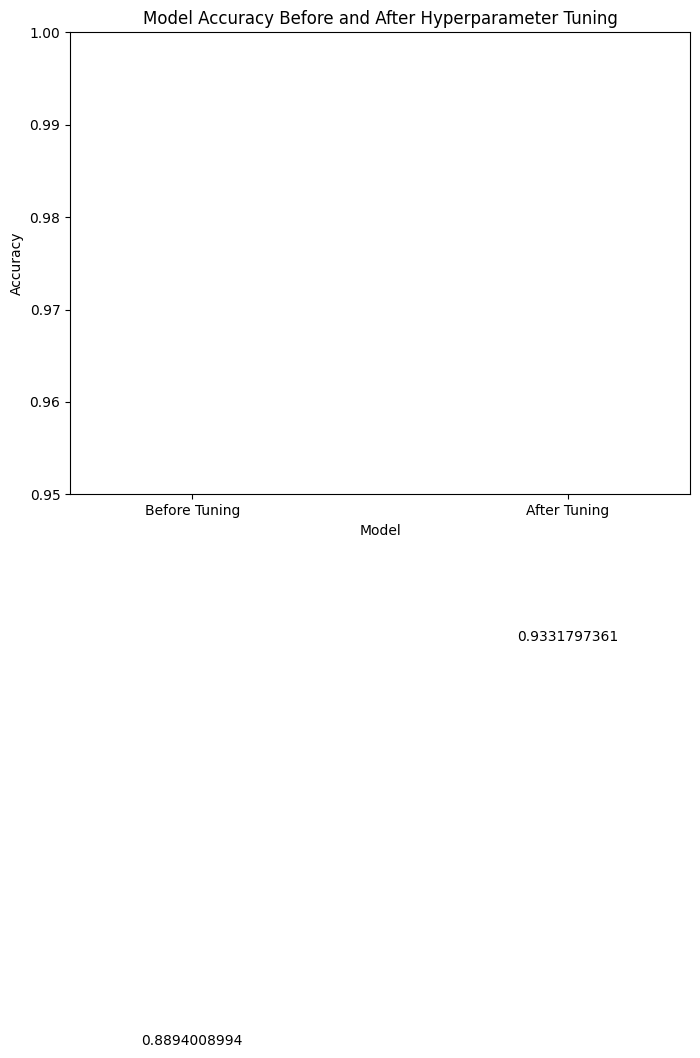

In [20]:
import matplotlib.pyplot as plt

# Prepare data for histogram
accuracies = [accuracy_before, accuracy_after]
labels = ['Before Tuning', 'After Tuning']

# Draw the histogram
plt.figure(figsize=(8, 6))
plt.bar(labels, accuracies, color=['blue', 'green'], width=0.5)

# Add titles and labels
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Before and After Hyperparameter Tuning')
plt.ylim(0.95, 1.0)  # Adjust y-axis to better visualize differences

# Show the accuracy values on top of the bars
for i in range(len(accuracies)):
    plt.text(i, accuracies[i] + 0.001, f'{accuracies[i]:.10f}', ha='center')

# Display the plot
plt.show()